What is the most optimal skill to learn for data analysts?

Methodology

1.Group skillls to determine median salary and likelihood of being in a posting
2.visualize median salry vs percent skill demand
3.Determine if certain technologies are more prevalent

In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

from adjustText import adjust_text

#Loading data
dataset = load_dataset ('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


def clean_list(skill_list):
 if pd.notna(skill_list):
    return ast.literal_eval(skill_list)

df['job_skills']= df['job_skills'].apply(clean_list)

c:\Users\hp\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

df_DA_USA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_USA = df_DA_USA.dropna(subset=['salary_year_avg'])

df_DA_USA_exploded = df_DA_USA.explode('job_skills')

df_DA_USA_exploded[['salary_year_avg','job_skills']].head(5)

df_DA_Skills = df_DA_USA_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values( by = 'count' , ascending = False)

df_DA_Skills = df_DA_Skills.rename(columns={'count':'skill_count', 'median':'median_salary'})

DA_job_count = len(df_DA_USA)

df_DA_Skills['skill_percent'] = df_DA_Skills['skill_count'] / DA_job_count *100

skill_percent = 5

df_DA_skills_high_demand = df_DA_Skills[df_DA_Skills['skill_percent'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


<function matplotlib.pyplot.show(close=None, block=None)>

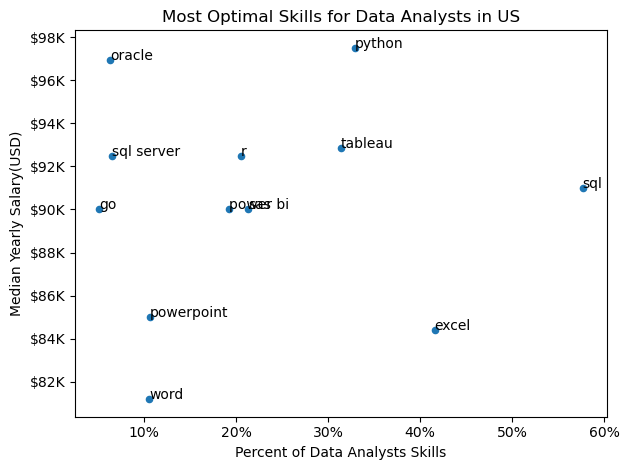

In [3]:
df_DA_skills_high_demand.plot(kind = 'scatter', x = 'skill_percent', y = 'median_salary')
texts = []

for i, txt in enumerate(df_DA_skills_high_demand.index):
  texts.append (plt.text(df_DA_skills_high_demand ['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))
#adjust_text(texts, arrowprops = dict (arrowstyle = '->', color = 'r',lw ='0.5'))


from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter( lambda y, pos: f'${int (y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals = 0))


plt.ylabel('Median Yearly Salary(USD)')
plt.xlabel('Percent of Data Analysts Skills')
plt.title('Most Optimal Skills for Data Analysts in US') 
plt.tight_layout()
plt.show

In [4]:
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,None,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [5]:
df_technology = df['job_type_skills'].copy()

#remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NAN values
df_technology = df_technology.dropna()

#combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row) #convert string into a dictionary
    for key, value in row_dict.items():
        if key in technology_dict:   #if key already exists in technology_dict. add value
            technology_dict[key] += value
        else:                       #if key does not exist in technology_dict. add key and value
            technology_dict[key] = value

#remove duplicates by converting to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['looker',
  'datarobot',
  'tableau',
  'nuix',
  'ssis',
  'outlook',
  'powerpoint',
  'splunk',
  'sheets',
  'dax',
  'msaccess',
  'alteryx',
  'esquisse',
  'spreadsheet',
  'ssrs',
  'spss',
  'sap',
  'word',
  'sas',
  'visio',
  'microstrategy',
  'power bi',
  'qlik',
  'powerbi',
  'excel',
  'cognos',
  'sharepoint',
  'ms access'],
 'programming': ['vba',
  'mongodb',
  'javascript',
  'powershell',
  'r',
  'java',
  'erlang',
  'cobol',
  'golang',
  't-sql',
  'sql',
  'apl',
  'pascal',
  'typescript',
  'c++',
  'solidity',
  'vb.net',
  'clojure',
  'sass',
  'php',
  'c',
  'julia',
  'nosql',
  'html',
  'swift',
  'shell',
  'python',
  'f#',
  'fortran',
  'assembly',
  'go',
  'sas',
  'css',
  'objective-c',
  'ocaml',
  'matlab',
  'bash',
  'dart',
  'lua',
  'elixir',
  'visualbasic',
  'lisp',
  'crystal',
  'haskell',
  'kotlin',
  'mongo',
  'ruby',
  'scala',
  'rust',
  'c#',
  'delphi',
  'groovy',
  'no-sql',
  'perl',
  'visual ba

In [6]:
pd.DataFrame(list(technology_dict.items()) , columns = ['technology', 'skills'])

df_technology = pd.DataFrame(list(technology_dict.items()) , columns = ['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,looker
0,analyst_tools,datarobot
0,analyst_tools,tableau
0,analyst_tools,nuix
0,analyst_tools,ssis
...,...,...
9,sync,google chat
9,sync,unify
9,sync,slack
9,sync,zoom


In [7]:

df_technology = df_technology.drop_duplicates(subset=['skills'])



In [8]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

df_plot

,skill_count,median_salary,skill_percent,technology,skills
0,2508,91000.00,57.655172,programming,sql
1,1808,84392.00,41.563218,analyst_tools,excel
2,1431,97500.00,32.896552,programming,python
3,1364,92875.00,31.356322,analyst_tools,tableau
4,926,90000.00,21.287356,analyst_tools,sas
5,893,92500.00,20.528736,programming,r
6,838,90000.00,19.264368,analyst_tools,power bi
7,462,85000.00,10.620690,analyst_tools,powerpoint
8,461,81194.75,10.597701,analyst_tools,word
9,286,92500.00,6.574713,databases,sql server


<function matplotlib.pyplot.show(close=None, block=None)>

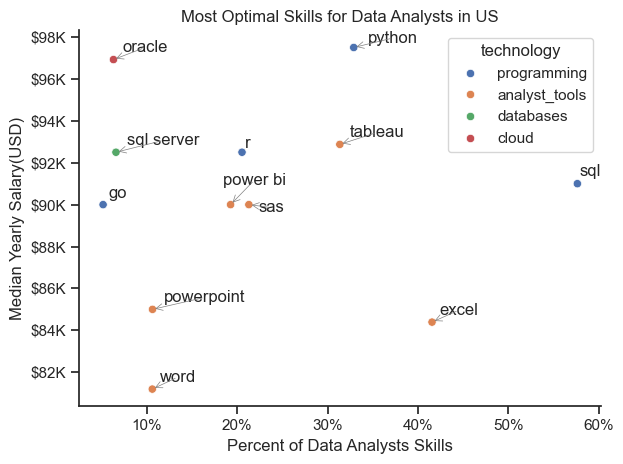

In [21]:


import numpy as np

df_plot['skill_percent_jitter'] = df_plot['skill_percent'] + np.random.uniform(-0.5, 0.5, len(df_plot))


sns.scatterplot(data= df_plot, x='skill_percent', y= 'median_salary', hue='technology')
sns.despine()
sns.set_theme(style = 'ticks')
texts = []

# for i, txt in enumerate(df_plot.skills):
#  texts.append (plt.text(df_plot ['skill_percent'].iloc[i], df_plot['median_salary'].iloc[i], txt))
# adjust_text(texts, arrowprops = dict (arrowstyle = '->', color = 'r',lw =0.5))

for i, txt in enumerate(df_plot.skills):
    x = df_plot['skill_percent'].iloc[i]
    y = df_plot['median_salary'].iloc[i]

    # if txt == 'sas':
    #     plt.text(x,y -1, txt)
    # elif txt == 'power bi':
    #     plt.text(x,y -1, txt)
    # else:
    texts.append(plt.text(x, y, txt))

adjust_text(
    texts,
    force_points=0.5,
    force_text=1.5,
    expand=(1.5,1.5),
    arrowprops=dict(arrowstyle='->', color='grey', lw=0.5)
)


from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter( lambda y, pos: f'${int (y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals = 0))


plt.ylabel('Median Yearly Salary(USD)')
plt.xlabel('Percent of Data Analysts Skills')
plt.title('Most Optimal Skills for Data Analysts in US') 
plt.tight_layout()
plt.show